# DL Final Project -- MLP for YouTube View Count Classification

## Goal

Build a MLP to classify YouTube videos into **4 view count categories**.

## Class Labels

| Label | Class | view_count range |
|-------|-------|------------------|
| 0 | Low | < 10,000 |
| 1 | Medium | 10,000 ~ 100,000 |
| 2 | High | 100,000 ~ 300,000 |
| 3 | Viral | ≥ 300,000 |

## Input Features

1. `subscriber_count` — 頻道總訂閱數 (`log1p` 轉換)
2. `video_duration_sec` — 影片長度（秒） (`log1p` 轉換)
3. `categoryId` — 影片分類 ID（排除 10，one-hot encoding）
4. `published_at` — 發布時間（cyclic encoding: `hour_sin`/`cos`, `weekday_sin`/`cos`）
5. `tag_count` — tags 數量 (數值轉換，缺失值補0)
6. `description_length` — description 字元長度 (`log1p` 轉換)
7. `channel_view_count` — 頻道總觀看數 (`log1p` 轉換)
8. `channel_video_count` — 頻道總影片數 (`log1p` 轉換)

## Settings

- Train / Val / Test split: stratified 68% / 12% / 20%
- Epochs: 100（跑滿；依 Val Macro F1 存最佳 checkpoint）
- Batch size: 64
- Loss: CrossEntropyLoss（可選**溫和**類別加權，`CLASS_WEIGHT_POWER`）
- Optimizer: Adam

## Part 1

Clone the dataset from GitHub and import necessary libraries.

In [104]:
!git clone https://github.com/Anson-ntuim/DL-Final.git

fatal: destination path 'DL-Final' already exists and is not an empty directory.


## Part 2

Import libraries.

In [105]:
# Model
import os
import torch
import torch.nn as nn
from torch.optim.optimizer import Optimizer

# Dataset
from torch.utils.data import Dataset, DataLoader, random_split

# Pre-processing
import pandas as pd
import numpy as np
import json
import re
from datetime import datetime, timezone
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

## Part 3

Global variables / hyperparameters.

In [106]:
batch_size = 64
num_epoch  = 200
learning_rate = 0.0001
train_ratio   = 0.8
num_classes   = 4    # 4 個分類
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# 分類邊界定義
# Class 0: view_count < 10,000
# Class 1: 10,000 <= view_count < 100,000
# Class 2: 100,000 <= view_count < 300,000
# Class 3: view_count >= 300,000
CLASS_BOUNDARIES = [10_000, 100_000, 300_000]
CLASS_NAMES = ['Low (<10K)', 'Medium (10K~100K)', 'High (100K~300K)', 'Viral (≥300K)']

SEED = 42
val_ratio = 0.15              # 從 train 再切 15% 做 validation
CLASS_WEIGHT_POWER = 0.0      # 0=不加權(原本~0.55)；0.3~0.5=溫和加權可再試
USE_EARLY_STOP = False        # True 可能提早停在不適合 test 的 epoch
early_stop_patience = 25

Using device: cuda


## Part 4

Data loading and preprocessing.

- Parse ISO 8601 duration → seconds
- Parse `published_at` → hour of day + day of week (cyclic encoding)
- Remove rows where `categoryId == 10`
- Fill missing values (tag_count → 0, description_length → 0)
- StandardScaler normalization on all features
- **Target: 4-class label based on view_count thresholds**
  - Class 0: view_count < 10,000
  - Class 1: 10,000 ≤ view_count < 100,000
  - Class 2: 100,000 ≤ view_count < 300,000
  - Class 3: view_count ≥ 300,000

In [107]:
# ── 工具函式 ────────────────────────────────────────────────

def parse_iso8601_duration(duration_str):
    """ISO 8601 duration (e.g. PT1H2M3S) → seconds (int)"""
    if not isinstance(duration_str, str):
        return 0
    pattern = r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
    match = re.match(pattern, duration_str)
    if not match:
        return 0
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h * 3600 + m * 60 + s


def parse_published_at(dt_str):
    """ISO 8601 datetime → (hour_of_day, day_of_week)"""
    try:
        dt = datetime.fromisoformat(dt_str.replace('Z', '+00:00'))
        return dt.hour, dt.weekday()   # 0-23, 0-6
    except Exception:
        return 0, 0


def view_count_to_label(view_count):
    """view_count → class label (0, 1, 2, 3)"""
    if view_count < 10_000:
        return 0
    elif view_count < 100_000:
        return 1
    elif view_count < 300_000:
        return 2
    else:
        return 3


class StandardScaler:
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_  = X.std(axis=0) + 1e-8
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_


# ── 讀取資料 ────────────────────────────────────────────────
# data_dir = 'DL-Final/data'
# files = os.listdir(data_dir)

# 直接載入位於 /content/ 的 tw_youtube_videos.jsonl 檔案
file_path = '/content/tw_youtube_videos.jsonl'
df = pd.read_json(file_path, lines=True)

print(f'Loaded data shape={df.shape}')

Loaded data shape=(12046, 29)


In [108]:
# ── 特徵工程 ────────────────────────────────────────────────

# 1. 移除 category_id == 10
if 'category_id' in df.columns:
    df = df[df['category_id'] != 10].copy()

# 2. 處理類別型特徵：One-hot Encoding for category_id
df['category_id'] = df['category_id'].astype(str)
df_encoded = pd.get_dummies(df, columns=['category_id'], prefix='cat')

# 3. 數值特徵轉換
if 'duration_iso8601' in df.columns:
    df_encoded['video_duration_sec'] = df['duration_iso8601'].apply(parse_iso8601_duration)

if 'published_at' in df.columns:
    df_encoded[['pub_hour', 'pub_weekday']] = df['published_at'].apply(
        lambda x: pd.Series(parse_published_at(str(x)))
    )

    # 週期性編碼 (Cyclic Encoding) for pub_hour and pub_weekday
    df_encoded['pub_hour_sin']     = np.sin(2 * np.pi * df_encoded['pub_hour']    / 24.0)
    df_encoded['pub_hour_cos']     = np.cos(2 * np.pi * df_encoded['pub_hour']    / 24.0)
    df_encoded['pub_weekday_sin']  = np.sin(2 * np.pi * df_encoded['pub_weekday'] / 7.0)
    df_encoded['pub_weekday_cos']  = np.cos(2 * np.pi * df_encoded['pub_weekday'] / 7.0)

# 確保數值型欄位為數值，並處理潛在的非數值資料
for col in ['subscriber_count', 'description_length', 'channel_view_count', 'channel_video_count', 'tags_count']:
    if col in df_encoded.columns:
        df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce').fillna(0)

# subscriber_count / duration / description 壓縮至 log scale
df_encoded['subscriber_count']   = np.log1p(df_encoded['subscriber_count'])
df_encoded['video_duration_sec'] = np.log1p(df_encoded['video_duration_sec'])
df_encoded['description_length'] = np.log1p(df_encoded['description_length'])
df_encoded['channel_view_count'] = np.log1p(df_encoded['channel_view_count'])
df_encoded['channel_video_count'] = np.log1p(df_encoded['channel_video_count'])


# 4. 建立特徵清單 (包含 One-hot 後的欄位)
CAT_COLS = [col for col in df_encoded.columns if col.startswith('cat_')]
NUM_COLS = ['subscriber_count', 'video_duration_sec', 'tags_count', 'description_length',
            'pub_hour_sin', 'pub_hour_cos', 'pub_weekday_sin', 'pub_weekday_cos',
            'channel_view_count','channel_video_count']
FEATURE_COLS = CAT_COLS + NUM_COLS

X = df_encoded[FEATURE_COLS].values.astype(np.float32)
input_dim = X.shape[1]

# ── 建立分類標籤 ────────────────────────────────────────────
view_col = 'view_count' if 'view_count' in df.columns else 'viewCount'
y = df[view_col].values.astype(np.int64)
y = np.array([view_count_to_label(v) for v in y], dtype=np.int64)

print(f'Feature matrix shape: {X.shape}')
print(f'Label distribution:')
for i, name in enumerate(CLASS_NAMES):
    count = (y == i).sum()
    print(f'  Class {i} [{name}]: {count} samples ({count/len(y)*100:.1f}%)')

display(df_encoded[FEATURE_COLS].head(5))

Feature matrix shape: (10254, 24)
Label distribution:
  Class 0 [Low (<10K)]: 2632 samples (25.7%)
  Class 1 [Medium (10K~100K)]: 3574 samples (34.9%)
  Class 2 [High (100K~300K)]: 1402 samples (13.7%)
  Class 3 [Viral (≥300K)]: 2646 samples (25.8%)


,cat_1,cat_15,cat_17,cat_19,cat_2,cat_20,cat_22,cat_23,cat_24,cat_25,...,subscriber_count,video_duration_sec,tags_count,description_length,pub_hour_sin,pub_hour_cos,pub_weekday_sin,pub_weekday_cos,channel_view_count,channel_video_count
0,False,False,False,False,False,True,False,False,False,False,...,12.955130,6.206576,28,6.349139,7.071068e-01,0.707107,0.781831,0.623490,19.447769,8.155936
1,False,False,False,False,True,False,False,False,False,False,...,0.000000,6.948897,22,7.614805,-7.071068e-01,-0.707107,0.433884,-0.900969,0.000000,0.000000
3,False,False,False,False,False,False,False,False,False,False,...,0.000000,3.951244,0,6.056784,0.000000e+00,1.000000,-0.433884,-0.900969,0.000000,0.000000
4,False,False,False,False,False,True,False,False,False,False,...,11.911708,6.284134,60,5.913503,7.071068e-01,-0.707107,-0.974928,-0.222521,17.350076,6.291569
5,False,False,False,False,True,False,False,False,False,False,...,0.000000,7.542744,83,7.485492,1.224647e-16,-1.000000,0.974928,-0.222521,0.000000,0.000000


## Part 5

Create Dataset and DataLoader with **stratified** train / val / test split.

- 80% train+val / 20% test（stratified）
- 從 train 再切 15% 為 validation（stratified）
- 訓練集一般 `shuffle=True`（**不用** WeightedRandomSampler，避免過度偏向少數類）

In [109]:
class YouTubeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def print_split_dist(name, labels):
    print(f'{name} ({len(labels)} samples):')
    for i, cname in enumerate(CLASS_NAMES):
        cnt = (labels == i).sum()
        print(f'  Class {i} [{cname}]: {cnt} ({cnt / len(labels) * 100:.1f}%)')


np.random.seed(SEED)
torch.manual_seed(SEED)

idx = np.arange(len(X))
trainval_idx, test_idx = train_test_split(
    idx, test_size=1 - train_ratio, random_state=SEED, stratify=y
)
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y[trainval_idx],
)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]
X_test, y_test   = X[test_idx], y[test_idx]

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

train_dataset = YouTubeDataset(X_train, y_train)
val_dataset   = YouTubeDataset(X_val, y_val)
test_dataset  = YouTubeDataset(X_test, y_test)

if CLASS_WEIGHT_POWER > 0:
    class_weights_np = compute_class_weight(
        'balanced', classes=np.arange(num_classes), y=y_train
    )
    class_weights_np = class_weights_np ** CLASS_WEIGHT_POWER
    class_weights_np = class_weights_np / class_weights_np.mean()
else:
    class_weights_np = np.ones(num_classes, dtype=np.float32)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print_split_dist('Train', y_train)
print_split_dist('Val', y_val)
print_split_dist('Test', y_test)
print(f'\nClass weights (power={CLASS_WEIGHT_POWER}): {np.round(class_weights_np, 3)}')

Train (6972 samples):
  Class 0 [Low (<10K)]: 1789 (25.7%)
  Class 1 [Medium (10K~100K)]: 2430 (34.9%)
  Class 2 [High (100K~300K)]: 954 (13.7%)
  Class 3 [Viral (≥300K)]: 1799 (25.8%)
Val (1231 samples):
  Class 0 [Low (<10K)]: 316 (25.7%)
  Class 1 [Medium (10K~100K)]: 429 (34.8%)
  Class 2 [High (100K~300K)]: 168 (13.6%)
  Class 3 [Viral (≥300K)]: 318 (25.8%)
Test (2051 samples):
  Class 0 [Low (<10K)]: 527 (25.7%)
  Class 1 [Medium (10K~100K)]: 715 (34.9%)
  Class 2 [High (100K~300K)]: 280 (13.7%)
  Class 3 [Viral (≥300K)]: 529 (25.8%)

Class weights (power=0.0): [1. 1. 1. 1.]


## Part 6

Activation function — ReLU (custom implementation).

In [110]:
class myActivation(nn.Module):

    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()

    def forward(self, x):
        # ReLU: max(0, x)
        return self.relu(x)

## Part 7

MLP model architecture.

- Input: same features as regression version
- Hidden layers: 1024 → 512 → 256 → 64
- **Output: 4 (classification logits, one per class)**
- Activation: ReLU
- BatchNorm for stable training

In [111]:
class myMLP(nn.Module):
    def __init__(self, input_dim, num_classes=4,dropoutRate=0.1):
        super(myMLP, self).__init__()
        self.mlp = nn.Sequential(

          #  'Model_C': [1024, 512, 256, 128, 64],  lr=0.0001  wd=1e-03  dr=0.1
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            myActivation(),
            nn.Dropout(dropoutRate),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            myActivation(),
            nn.Dropout(dropoutRate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            myActivation(),
            nn.Dropout(dropoutRate),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            myActivation(),
            nn.Dropout(dropoutRate),

            nn.Linear(128, 64),
            myActivation(),

            nn.Linear(64, num_classes)   # 輸出 4 個 logits (不加 Softmax，由 CrossEntropyLoss 處理)
        )

    def forward(self, x):
        return self.mlp(x)

model = myMLP(input_dim, num_classes=num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 726,980


## Part 8

Loss function — Cross Entropy（`CLASS_WEIGHT_POWER=0` 時與原版相同；>0 時為溫和加權）。

In [112]:
class myLoss(nn.Module):
    def __init__(self, weight=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight)

    def forward(self, pred, target):
        return self.ce(pred, target)

if CLASS_WEIGHT_POWER > 0:
    class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)
    criterion = myLoss(weight=class_weights)
    print(f'Using mild weighted CE (power={CLASS_WEIGHT_POWER})')
    for i, w in enumerate(class_weights_np):
        print(f'  Class {i} [{CLASS_NAMES[i]}]: weight={w:.3f}')
else:
    criterion = myLoss()
    print('Using standard CrossEntropyLoss (no class weight)')

Using standard CrossEntropyLoss (no class weight)


## Part 9

Optimizer — Adam with weight decay.

In [113]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)

## Part 10

Model training（跑滿 epoch；依 Val Macro F1 存最佳模型；prior 校正僅在 validation 有幫助時才用）。

In [114]:
def eval_macro_f1(model, loader, log_bias=None):
    model.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x = x.to(device).float()
            logits = model(x)
            if log_bias is not None:
                logits = logits + log_bias
            preds = torch.argmax(logits, dim=1)
            preds_list.append(preds.cpu())
            labels_list.append(y_batch.cpu())
    preds = torch.cat(preds_list).numpy()
    labels = torch.cat(labels_list).numpy()
    return f1_score(labels, preds, average='macro')


def tune_log_bias(model, loader):
    """在 validation 上搜尋 prior 校正強度，最大化 Macro F1。"""
    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for x, y_batch in loader:
            logits_list.append(model(x.to(device).float()).cpu())
            labels_list.append(y_batch.cpu())
    logits = torch.cat(logits_list).numpy()
    labels = torch.cat(labels_list).numpy()

    priors = np.array([(y_train == i).mean() for i in range(num_classes)])
    log_prior = np.log(priors + 1e-8)

    best_f1, best_scale = -1.0, 0.0
    for scale in np.linspace(-1.5, 1.5, 31):
        preds = np.argmax(logits - scale * log_prior, axis=1)
        f1 = f1_score(labels, preds, average='macro')
        if f1 > best_f1:
            best_f1, best_scale = f1, scale

    log_bias = torch.tensor(-best_scale * log_prior, dtype=torch.float32, device=device)
    return log_bias, best_f1, best_scale


model.train()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15
)

best_val_f1 = -1.0
best_epoch = 0
epochs_no_improve = 0
BEST_MODEL_PATH = 'best_mlp_cls_model_state_dict.pt'

for epoch in range(num_epoch):
    model.train()
    losses = []

    for x, y_batch in train_loader:
        optimizer.zero_grad()
        x = x.to(device).float()
        y_batch = y_batch.to(device).long()

        output = model(x)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())

    avg_loss = sum(losses) / len(losses)
    val_f1 = eval_macro_f1(model, val_loader)
    scheduler.step(avg_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch + 1:3d}/{num_epoch} | Loss {avg_loss:.4f} | Val Macro F1 {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        epochs_no_improve += 1
        if USE_EARLY_STOP and epochs_no_improve >= early_stop_patience:
            print(f'Early stopping at epoch {epoch + 1} (best epoch {best_epoch}, Val Macro F1 {best_val_f1:.4f})')
            break

# 比較：最後一個 epoch vs Val F1 最佳 checkpoint
last_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
val_f1_best_ckpt = eval_macro_f1(model, val_loader)

model.load_state_dict(last_state)
val_f1_last = eval_macro_f1(model, val_loader)

if val_f1_best_ckpt >= val_f1_last:
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    print(f'\nUsing best Val-F1 checkpoint (epoch {best_epoch}, Val Macro F1 {val_f1_best_ckpt:.4f})')
else:
    print(f'\nUsing last epoch (Val Macro F1 {val_f1_last:.4f} > best-ckpt {val_f1_best_ckpt:.4f})')

# prior 校正：僅在 validation 真的變好時才套用到 test  (post-processing)(改logits 讓class3被猜中的機會較大)
log_bias_zero = torch.zeros(num_classes, device=device)
val_f1_plain = eval_macro_f1(model, val_loader, log_bias=log_bias_zero)
log_bias, val_f1_tuned, bias_scale = tune_log_bias(model, val_loader)

if val_f1_tuned > val_f1_plain + 1e-4:
    print(f'Prior correction ON  (scale={bias_scale:.2f}, Val F1 {val_f1_plain:.4f} -> {val_f1_tuned:.4f})')
else:
    log_bias = log_bias_zero
    print(f'Prior correction OFF (plain Val F1 {val_f1_plain:.4f} >= tuned {val_f1_tuned:.4f})')

torch.save(model.state_dict(), 'final_mlp_cls_model_state_dict.pt')
print('Saved final_mlp_cls_model_state_dict.pt')

Epoch   1/200 | Loss 1.2596 | Val Macro F1 0.4039
Epoch   5/200 | Loss 1.0715 | Val Macro F1 0.4453
Epoch  10/200 | Loss 1.0117 | Val Macro F1 0.4736
Epoch  15/200 | Loss 0.9791 | Val Macro F1 0.4954
Epoch  20/200 | Loss 0.9632 | Val Macro F1 0.4994
Epoch  25/200 | Loss 0.9333 | Val Macro F1 0.5418
Epoch  30/200 | Loss 0.9233 | Val Macro F1 0.5247
Epoch  35/200 | Loss 0.9126 | Val Macro F1 0.5303
Epoch  40/200 | Loss 0.8902 | Val Macro F1 0.5283
Epoch  45/200 | Loss 0.8738 | Val Macro F1 0.5300
Epoch  50/200 | Loss 0.8660 | Val Macro F1 0.5417
Epoch  55/200 | Loss 0.8468 | Val Macro F1 0.5263
Epoch  60/200 | Loss 0.8402 | Val Macro F1 0.5321
Epoch  65/200 | Loss 0.8195 | Val Macro F1 0.5349
Epoch  70/200 | Loss 0.8132 | Val Macro F1 0.5332
Epoch  75/200 | Loss 0.8020 | Val Macro F1 0.5162
Epoch  80/200 | Loss 0.7807 | Val Macro F1 0.5191
Epoch  85/200 | Loss 0.7728 | Val Macro F1 0.5412
Epoch  90/200 | Loss 0.7723 | Val Macro F1 0.5356
Epoch  95/200 | Loss 0.7516 | Val Macro F1 0.5379


## Part 11

Model evaluation on **test set**（最佳/最後 epoch 模型；prior 校正僅在 validation 有提升時啟用）。

Metrics:
- Overall / per-class Accuracy
- **Macro F1**、per-class F1
- Confusion Matrix

In [115]:
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y_batch in test_loader:
        x = x.to(device).float()
        logits = model(x) + log_bias #post-processing
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(y_batch.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_labels = torch.cat(all_labels, dim=0)

preds_np = all_preds.numpy()
labels_np = all_labels.numpy()

overall_acc = (all_preds == all_labels).float().mean().item()
macro_f1 = f1_score(labels_np, preds_np, average='macro')

print('=' * 55)
print(f'Test Overall Accuracy: {overall_acc * 100:.2f}%')
print(f'Test Macro F1-score:     {macro_f1:.4f}')
print('=' * 55)

print('\nPer-class Accuracy:')
for i, name in enumerate(CLASS_NAMES):
    mask = labels_np == i
    if mask.sum() == 0:
        print(f'  Class {i} [{name}]: N/A')
    else:
        cls_acc = (preds_np[mask] == labels_np[mask]).mean()
        print(f'  Class {i} [{name}]: {cls_acc * 100:.2f}% ({mask.sum()} samples)')

print('\nClassification report (per-class precision / recall / F1):')
print(classification_report(labels_np, preds_np, target_names=CLASS_NAMES, digits=4))

Test Overall Accuracy: 56.80%
Test Macro F1-score:     0.5348

Per-class Accuracy:
  Class 0 [Low (<10K)]: 65.84% (527 samples)
  Class 1 [Medium (10K~100K)]: 56.64% (715 samples)
  Class 2 [High (100K~300K)]: 30.36% (280 samples)
  Class 3 [Viral (≥300K)]: 62.00% (529 samples)

Classification report (per-class precision / recall / F1):
                   precision    recall  f1-score   support

       Low (<10K)     0.5561    0.6584    0.6030       527
Medium (10K~100K)     0.6240    0.5664    0.5938       715
 High (100K~300K)     0.3664    0.3036    0.3320       280
    Viral (≥300K)     0.6007    0.6200    0.6102       529

         accuracy                         0.5680      2051
        macro avg     0.5368    0.5371    0.5348      2051
     weighted avg     0.5654    0.5680    0.5647      2051



## Part 12

Visualize results — Confusion Matrix and class distribution.

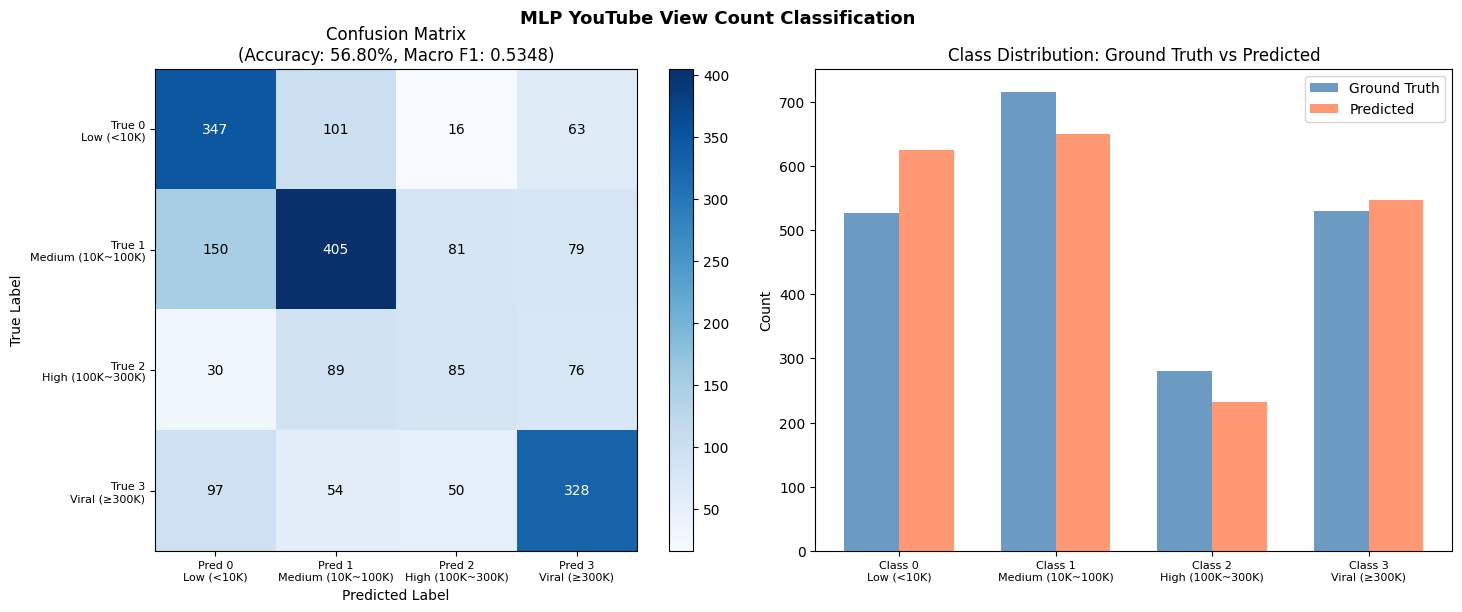

Plot saved as classification_analysis.png


In [116]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

preds_np  = all_preds.numpy()
labels_np = all_labels.numpy()

# ── Confusion Matrix ────────────────────────────────────────
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(labels_np, preds_np):
    conf_matrix[t][p] += 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左圖：Confusion Matrix
im = axes[0].imshow(conf_matrix, cmap='Blues')
axes[0].set_xticks(range(num_classes))
axes[0].set_yticks(range(num_classes))
axes[0].set_xticklabels([f'Pred {i}\n{n}' for i, n in enumerate(CLASS_NAMES)], fontsize=8)
axes[0].set_yticklabels([f'True {i}\n{n}' for i, n in enumerate(CLASS_NAMES)], fontsize=8)
for i in range(num_classes):
    for j in range(num_classes):
        axes[0].text(j, i, str(conf_matrix[i][j]),
                     ha='center', va='center',
                     color='white' if conf_matrix[i][j] > conf_matrix.max() / 2 else 'black')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title(f'Confusion Matrix\n(Accuracy: {overall_acc*100:.2f}%, Macro F1: {macro_f1:.4f})')
plt.colorbar(im, ax=axes[0])

# 右圖：Class distribution (真實 vs 預測)
x_pos = np.arange(num_classes)
true_counts = [(labels_np == i).sum() for i in range(num_classes)]
pred_counts = [(preds_np  == i).sum() for i in range(num_classes)]

width = 0.35
axes[1].bar(x_pos - width/2, true_counts, width, label='Ground Truth', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + width/2, pred_counts, width, label='Predicted',    color='coral',     alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Class {i}\n{n}' for i, n in enumerate(CLASS_NAMES)], fontsize=8)
axes[1].set_ylabel('Count')
axes[1].set_title('Class Distribution: Ground Truth vs Predicted')
axes[1].legend()

plt.suptitle('MLP YouTube View Count Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved as classification_analysis.png')